<a href="https://colab.research.google.com/github/Valerachik/Lab_1/blob/main/Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота №1

## **Завдання 1: «Аналіз великих даних у хмарному середовищі Google Colab»**

---

### **Завдання**

Використати відкритий набір даних Titanic dataset (інформація про пасажирів та їх
виживання).

Посилання на датасет:
https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv

Створити новий блокнот у середовищі Google Colab.

Перевірити доступні апаратні ресурси:
*   визначити операційну систему;
*   визначити кількість процесорів CPU.

Завантажити відкритий набір даних Titanic із мережі Інтернет.
Вивести перші 5 рядків таблиці для ознайомлення зі структурою даних.

Проаналізувати структуру даних:

*   визначити типи даних;
*   знайти пропущені значення.

Виконати агрегацію даних:

*   визначити кількість пасажирів у кожному класі (pclass);
*   визначити кількість тих, хто вижив у кожному класі.

Створити зведену таблицю (pivot table), що показує кількість тих, хто вижив залежно від класу
пасажира та статі.

Побудувати графік, що відображає кількість пасажирів у різних класах кают. Проаналізувати отримані
результати та зробити висновки.

### **Апаратні ресурси**
Перевіримо доступні апаратні ресурси:

In [ ]:
import platform
import multiprocessing
print("Операційна система:", platform.system())
print("Кількість CPU:", multiprocessing.cpu_count())

Операційна система: Linux
Кількість CPU: 2


Отже, робимо висновки що апаратура на якій виконується код має операційну систему Лінукс та 2 процесора CPU.

### **Завантаження датасету**

Виконаємо завантаження датасету за допомогою URL посилання:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
data = pd.read_csv(url)
display(data.head(5))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### **Перевірка даних**
Тепер зробимо перевірку завантаженого датасету та первинну перевірку якості даних:

In [8]:
#Переглянемо розмір таблиці
print(data.shape)

(891, 15)


In [9]:
#Переглянемо усі наявні стовпці в датасеті
print(data.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [10]:
#Передивимось інформацію про типи даних стовпців
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [11]:
#Переглянемо статистичну інформацію
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
#Перевіримо на наявність пропущеих значень
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [13]:
#Перевіримо кількість дублікатів
data.duplicated().sum()

np.int64(107)

Отже з даних перевірок можемо зробити висновки що в датасеті ми маємо такі типи даних в такій кількості: bool(2), float64(2), int64(4), object(7). Та маємо 177 пропущених значень в стовпці age, 2 пропущених значення в стовпці embarked, 688 пропущених значення в стовпці deck та 2 пропущених значення в стовпці embark_town.

### **Агрегація даних та зведена таблиця**

Виконаємо агрегацію даних:

In [16]:
#Кількість пасажирів у кожному класі
print(data['pclass'].value_counts().sort_index())

pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [17]:
#Кількість тих, хто вижив у кожному класі
print(data.groupby('pclass')['survived'].sum())

pclass
1    136
2     87
3    119
Name: survived, dtype: int64


Можемо зробити висновки що в I класі з 216 людей вижило 136, в II класі з 184 людей вижило 87, та в III класі з 491 людини вижило 119.

Тепер створимо зведену таблицю, що показує кількість тих, хто вижив залежно від класу пасажира та статі:

In [32]:
print(data.pivot_table(values='survived', index='pclass', columns='sex', aggfunc='sum'))

sex     female  male
pclass              
1           91    45
2           70    17
3           72    47


Зі створенної зведеної таблиці можемо зробити висновок, що в кожному з класів вижило більше жінок ніж чоловіків. Це пояснюється тим що під час аварії Титаніка впершу чергу рятули дітей та жінок.

Тепер побудуємо графік, що відображає кількість пасажирів у різних класах кают.

([<matplotlib.axis.XTick at 0x79da84ee4f50>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

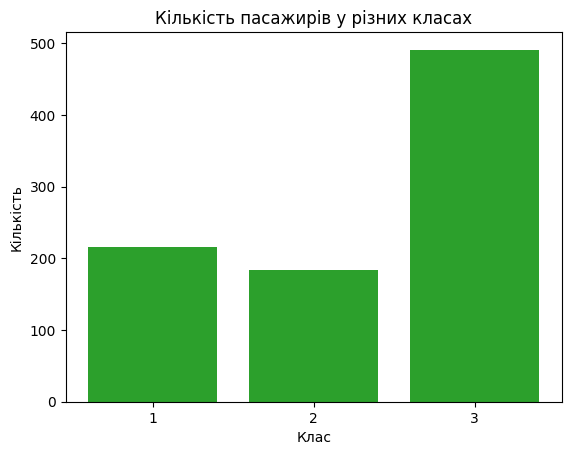

In [64]:
import matplotlib.pyplot as plt
passenger_per_class = data['pclass'].value_counts().sort_index()
plt.bar(passenger_per_class.index, passenger_per_class.values, color='C2')
plt.title('Кількість пасажирів у різних класах')
plt.xlabel('Клас')
plt.ylabel('Кількість')
plt.xticks([1, 2, 3])

З графіку можемо побачити що найбільше було людей у третьому класі, а найменше у другому.

### **Питання**

1. Що таке великі дані (Big Data) та які їх основні характеристики?

Це величезні масиви структурованих і неструктурованих даних, які складно обробити традиційними методами.

Основні характеристики: обсяг, швидкість генерації, різноманітність форматів, достовірність та цінність.

2. Що таке хмарні обчислення та які їх основні переваги для аналізу великих даних?

Це надання обчислювальних ресурсів через мережу інтернет. Основні переваги: висока масштабованість, відсутність витрат на власне обладнання, доступність з будь-якої точки світу та оплата лише за використані ресурси.

3. Які моделі надання хмарних послуг існують (SaaS, PaaS, IaaS)?

IaaS це інфраструктура як послуга, тобто оренда віртуальних серверів.

PaaS це платформа як послуга, тобто середовище для розробки та розгортання додатків.

SaaS це ПЗ як послуга, тобто це готові програми через браузер.

4. Яке призначення середовища Google Colab та які його основні можливості для обробки даних?

Безкоштовне хмарне середовище від Google для написання та виконання коду на Python. Дозволяє працювати з даними без налаштування комп'ютера, підключати Google Drive та безкоштовно використовувати потужні сервери.

5. Які типи обчислювальних ресурсів доступні в Google Colab (CPU, GPU, TPU)? У чому полягає різниця між використанням CPU, GPU та TPU при обробці даних?

CPU: Центральний процесор, добре підходить для загальних і послідовних задач.

GPU: Відеокарта, ідеальна для паралельних обчислень.

TPU: Тензорний процесор від Google, спеціально створений для максимально швидкого навчання важких нейромереж.

6. Що таке платформа Kaggle та для яких завдань вона використовується? Які основні можливості надає Kaggle для роботи з наборами даних?

Платформа від Google для спеціалістів з Data Science. Використовується для пошуку безкоштовних датасетів, участі у змаганнях з машинного навчання, навчання та обміну кодом.

7. Які бібліотеки мови Python найчастіше застосовуються для аналізу даних?

Найчастіше використовують Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn.

8. Яке призначення бібліотеки Pandas у процесі аналітики даних?

Бібліотека для швидкого завантаження, очищення, фільтрації, групування та аналізу структурованих табличних даних.

9. Що таке DataFrame та які основні операції можна виконувати з цією структурою даних?

Це двовимірна структура даних у Pandas. З нею можна виконувати фільтрацію рядків, вибірку колонок, об'єднання кількох таблиць, агрегацію, сортування та заповнення пропусків.

10. Які способи імпорту даних у DataFrame існують у бібліотеці Pandas?

Способи: Читання з CSV - read_csv, Excel-файлів - read_excel, JSON - read_json, баз даних SQL - read_sql, або напряму з HTML-сторінок - read_html.

11. Що таке відкриті дані та які основні формати їх зберігання (CSV, JSON, XML)?

Це інформація, доступна для вільного використання будь-ким. Основні формати: CSV, JSON, XML.

12. Яке призначення функції read_csv() у бібліотеці Pandas?

Функція в Pandas для завантаження текстового файлу з розділювачами та його конвертації в об'єкт DataFrame для подальшого аналізу.

13. Що таке агрегація даних та для чого вона використовується в аналітиці великих даних?

Процес об'єднання мільйонів рядків у стислий вигляд шляхом обчислення математичних метрик.

14. Яке призначення методу pivot_table() та в яких задачах він застосовується?

Створює зведену таблицю, перетворюючи значення колонок на нові рядки чи стовпці.

15. Що таке описова статистика та які основні статистичні показники  використовуються для аналізу даних?

Розділ статистики для базового опису датасету. Основні показники: середнє арифметичне, медіана, мода, мінімум, максимум та стандартне відхилення, яке показує наскільки дані розсіяні.

16. Для чого використовуються засоби візуалізації даних у процесі аналітики?

Використовуються для швидкого виявлення неочевидних трендів, закономірностей, аномальних значень та спрощення сприйняття результатів нетехнічною аудиторією.

17. Які типи графіків використовуються для аналізу часових рядів?

Лінійні графіки, стовпчикові діаграми та свічкові графіки.

18. Яке призначення бібліотеки Matplotlib у Python?

Базова і найпопулярніша бібліотека Python для створення двовимірних статичних, анімованих та інтерактивних графіків.

19. Що таке часові ряди та які методи їх аналізу застосовуються у Big Data?

Це дані, зібрані послідовно через рівні проміжки часу. Методи аналізу включають: виявлення тренду, визначення сезонності, ковзне середнє та авторегресію.

20. Які етапи включає типовий процес аналізу великих даних у хмарному середовищі?

1) Збір та завантаження даних у хмарне сховище.

2) Попередня обробка та очищення.

3) Дослідницький аналіз та агрегація.

4) Побудова моделей.

5) Візуалізація та інтерпретація результатів.


## **Завдання 2: «Вебскрепінг даних»**


---



### **Завдання**
Потрібно використати відкритий навчальний сайт для вебскрепінгу Books to Scrape, який
містить інформацію про книги (назва, ціна, рейтинг).

Посилання: http://books.toscrape.com/

Потрібно:
1. Імпортувати необхідні бібліотеки Python.
2. Завантажити HTML-код головної сторінки сайту.
3. Виконати розбір HTML-документа.

4. Знайти елементи, що містять:

*   назву книги;
*   ціну книги.

5. Зібрати отримані дані у списки.
6. Створити таблицю даних у вигляді DataFrame за допомогою бібліотеки Pandas.
7. Вивести перші записи таблиці.
8. Зберегти отриманий набір даних у файл CSV.
9. Проаналізувати отримані результати та визначити:

*   кількість знайдених книг;
*   мінімальну та максимальну ціну.


### **Імпортування**
Для початку імортуємо усі потрібні бібліотеки, завантажимо код головної сторінки сайту та виконаємо розбір HTML документу:

In [65]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
url = 'http://books.toscrape.com/'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

### **Знаходження елементів**
Тепер знайдемо елементи, що містять назву книги та ціну книги та зберемо дані у списки:

In [68]:
books = soup.find_all('article', class_='product_pod')
titles = []
prices = []
for book in books:
    title = book.h3.a['title']
    price_text = book.find('p', class_='price_color').text
    price_clean = float(price_text.replace('£', '').replace('Â', ''))
    titles.append(title)
    prices.append(price_clean)

### **Таблица даних та аналіз**
Тепер створимо таблицю даних у вигляді DataFrame за допомогою бібліотеки Pandas та збережемо отриманий набір даних у файл CSV:

In [72]:
df_books = pd.DataFrame({
    'Title': titles,
    'Price (£)': prices
})
df_books.to_csv('books.csv', index=False)
df_books.head()

,Title,Price (£)
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23


Тепер проаналізуємо отримані результати та визначимо кількість знайдених книг, мінімальну та максимальну ціну книг:

In [73]:
total_count = len(df_books)
min_p = df_books['Price (£)'].min()
max_p = df_books['Price (£)'].max()
print(f"Кількість знайдених книг: {total_count}")
print(f"Мінімальна ціна книги: £{min_p}")
print(f"Максимальна ціна книги: £{max_p}")

Кількість знайдених книг: 20
Мінімальна ціна книги: £13.99
Максимальна ціна книги: £57.25


Отже, загалом знайдено було 20 книг та їх ціна варіюється від £13.99 до £57.25.

### **Питання**

1. Що таке вебскрепінг та для чого він використовується в аналітиці даних?

Це процес автоматизованого збору та витягування даних із вебсторінок. В аналітиці використовується для моніторингу цін, аналізу ринку та конкурентів, агрегації новин, збору відгуків та формування нових датасетів для моделей машинного навчання.

2. Які основні етапи процесу вебскрепінгу?

1) Надсилання HTTP-запиту до вебсервера;

2) Отримання HTML-коду сторінки;

3) Парсинг HTML-структури;

4) Пошук, витяг та очищення потрібних даних;

5) Збереження даних у структурованому вигляді.

3. Що таке HTML-документ і з яких основних елементів він складається?

Це текстовий файл зі спеціальною розміткою, який задає структуру вебсторінки. Складається з тегів, атрибутів, текстового контенту та двох основних розділів: head і body

4. Що таке DOM-структура вебсторінки?

Це деревоподібне представлення HTML-документа, де кожен тег є окремим об'єктом. Вона дозволяє програмно звертатися до будь-якого елемента сторінки та змінювати або зчитувати його вміст.

5. Які основні HTML-теги використовуються для структурування вебсторінки?

 html корінь, head заголовок документа, body тіло, div блок, span рядковий елемент, h1-h6 заголовки, p параграф, a посилання, table таблиця, ul/ol та li списки.

6. Яке призначення бібліотеки Requests у Python?

Бібліотека Python для зручного відправлення HTTP-запитів до вебсерверів, отримання відповіді та управління заголовками, кукі й авторизацією.

7. Які основні методи HTTP-запитів використовуються під час отримання вебданих?

GET — запит на отримання даних із сервера. POST — надсилання даних на сервер.

8. Що таке HTTP-відповідь та які її основні компоненти?

Це відповідь сервера на запит клієнта. Складається зі cтатус-коду, заголовківБ та тіла.

9. Яке призначення бібліотеки Beautiful Soup?

Використовується для швидкого парсингу HTML та XML документів, зручного переміщення по DOM-дереву та пошуку елементів за тегами, класами чи атрибутами.

10. Які основні можливості бібліотеки Beautiful Soup для пошуку елементів HTML?

Пошук за назвою тегу, атрибутами, пошук за CSS-селекторами, використання регулярних виразів та навігація між суміжними або батьківськими елементами DOM.

11. У чому різниця між методами find() та find_all() у Beautiful Soup?

find() повертає перший знайдений тег, що відповідає умовам.

find_all() повертає список усіх знайдених тегів, що відповідають умовам.

12. Що таке атрибути HTML-тегів і як їх використовувати під час вебскрепінгу?

Це параметри тегів у форматі "ключ-значення". Вони використовуються для точного фіксування потрібного елемента серед інших або для витягування посилань та шляхів до зображень

13. Які основні формати збереження отриманих даних використовуються в аналітиці
(CSV, JSON, Excel)?

CSV — плоскі таблиці, зручні для швидкого завантаження в Pandas чи Excel;

JSON — ключ-значення, ідеально для збереження складних вкладених та ієрархічних структур;

Excel — форматовані таблиці для звітності.

14. Яке призначення бібліотеки Pandas під час обробки отриманих даних?

Перетворення витягнутих сирих списків чи словників у табличний формат, очищення від дублікатів і пропусків, форматування типів даних та збереження у файл.

15. Що таке DataFrame та які його основні властивості?

Двовимірна таблична структура даних з підписаними вісями. Має такі властивості: підтримує гетерогенні типи даних, гнучке сортування, фільтрацію та агрегацію.

16. Які етичні та правові аспекти потрібно враховувати під час вебскрепінгу?

Необхідність дотримуватися умов використання сайту, не порушувати авторські права, додавати затримку між запитами, щоб не перевантажувати сервер

17. Що таке файл robots.txt і яку роль він відіграє при доступі до вебресурсів?

Текстовий файл у корінній папці сайту, де власник описує правила для автоматизованих ботів.

18. Які обмеження можуть виникати під час вебскрепінгу (CAPTCHA, блокування IP тощо)?

Блокування за IP-адресою при занадто частих запитах, капчі, використання JavaScript для динамічного завантаження даних, системи захисту.

19. Які інструменти розробника браузера використовуються для пошуку HTML-
елементів під час вебскрепінгу?

Inspect Element для пошуку тегів у DOM-дереві, вкладка Network для перехоплення внутрішніх API-запитів та вкладка Console для тестування селекторів.

20. У чому полягає роль вебскрепінгу у процесах аналізу великих даних?

Спеціалізується на етапі первинного збору неочищених зовнішніх даних з інтернету для подальшої обробки, завантаження у Data Lake та аналізу у системах великих даних.


## **Завдання 3: «Розподілені обчислення та обробка великих даних у середовищі Google Colab»**


---



### **Завдання**

Використати відкритий набір даних про автомобілі:
https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv
Набір містить інформацію про витрати палива автомобілів, потужність двигуна, масу автомобіля та інші
характеристики.

Потрібно:
1. Завантажити датасет у середовищі Google Colab.
2. Перетворити таблицю у Dask DataFrame.
3. Виконати аналіз даних:

*   визначити середню витрату палива для різних країн виробництва;
*   визначити максимальну потужність двигуна.

4. Побудувати графік залежності витрати палива від потужності двигуна.
5. Зробити короткі висновки щодо отриманих результатів.

### **Завантаження датасету**
Для початку завантажимо датасет та перетворимо таблицю у Dask DataFrame:

In [77]:
import pandas as pd
import dask.dataframe as dd
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv'
df = pd.read_csv(url)
ddf = dd.from_pandas(df, npartitions=2)
ddf.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### **Аналіз даних**
Тепер визначимо середню витрату палива для різних країн виробництва та максимальну потужність двигуна:

In [78]:
avg_mpg = ddf.groupby('origin')['mpg'].mean().compute()
print("--- Середнє значення миль на галон за країнами виробництва ---")
print(avg_mpg)

max_hp = ddf['horsepower'].max().compute()
print(f"\nМаксимальна потужність двигуна: {max_hp} к.с.")

--- Середнє значення mpg за країнами виробництва ---
origin
europe    27.891429
japan     30.450633
usa       20.083534
Name: mpg, dtype: float64

Максимальна потужність двигуна: 230.0 к.с.


### **Графік**
Побудуємо графік залежності витрати палива від потужності двигуна:

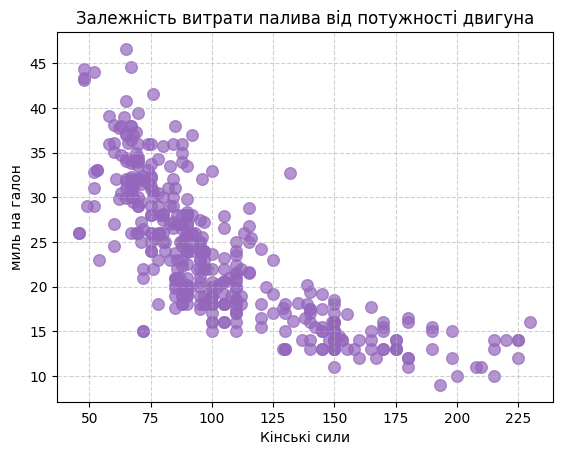

In [88]:
import matplotlib.pyplot as plt
df_plot = ddf.compute()
plt.scatter(
    df_plot['horsepower'],
    df_plot['mpg'],
    s=70,
    alpha=0.7,
    color='C4'
    )
plt.title('Залежність витрати палива від потужності двигуна')
plt.xlabel('Кінські сили')
plt.ylabel('миль на галон')
plt.show()

 Дивлячись на графік можемо сказати що автомобілі, що мають меншу витрату палива відповідно мають менш потужний двигун. Зворотньо автомобілі що мають більше кінських сил мають більшу витрату палива.

### **Питання**

1. Що таке розподілені обчислення та які їх основні принципи?

Це спосіб вирішення складного завдання шляхом його розбиття на дрібніші частини, які виконуються одночасно на різних комп'ютерах, з'єднаних у мережу. Основні принципи: децентралізація, паралелізм, відмовостійкість та прозорість.

2. Які основні переваги використання розподілених систем для обробки великих даних?

Здатність обробляти петабайти даних, висока швидкість завдяки паралелізму, надійність та горизонтальна масштабованість.

3. Які типи архітектур застосовуються у розподілених системах?

Клієнт-серверна, мікросервісна, багаторівнева та подійна.

4. Які основні характеристики великих даних (Big Data)?

Основні характеристики: обсяг, швидкість генерації, різноманітність форматів, достовірність та цінність.

5. Яку роль відіграє мова Python у системах аналізу великих даних?

Python є галузевим стандартом завдяки простому синтаксису, наявності потужних бібліотек для машинного навчання та математики, а також можливості легко інтегруватися з розподіленими фреймворками.

6. Які бібліотеки Python використовуються для розподілених обчислень великих даних?

PySpark, Dask, Ray, Vaex та Modin.

7. Яке призначення бібліотеки Dask?

Це бібліотека для паралельних обчислень у Python. Вона дозволяє розбити важкі задачі та великі датасети на менші фрагменти, щоб обробляти їх паралельно на всіх ядрах процесора або навіть на кластері серверів.

8. У чому відмінність між Pandas DataFrame і Dask DataFrame?

Pandas завантажує всю таблицю в оперативну пам'ять і працює в один потік, що викликає збій при нестачі пам'яті. Dask DataFrame складається з багатьох дрібних Pandas-таблиць, які завантажуються з диска по черзі і обробляються паралельно.

9. Що таке паралельні обчислення?

Одночасне виконання кількох частин одного завдання на різних процесорах або ядрах однієї обчислювальної машини для значного зменшення загального часу роботи.

10. Що таке багатопроцесорна обробка великих даних?

Використання кількох процесорів в межах однієї системи для одночасної обробки різних блоків інформації, що дозволяє обійти обмеження однопотоковості стандартного Python.

11. Які ресурси доступні у середовищі Google Colab?

Віртуальні машини з оперативною пам'яттю, дисковий простір та можливість підключення апаратних прискорювачів - CPU, GPU та TPU.

12. У чому різниця між CPU, GPU та TPU?

CPU: Центральний процесор, має мало потужних ядер, добре підходить для загальних і послідовних задач.

GPU: Відеокарта, має тисячі слабших ядер, ідеальна для паралельних обчислень.

TPU: Тензорний процесор від Google, спеціально створений для максимально швидкого навчання важких нейромереж.

13. Що таке агрегація даних у процесі аналітики?

Це процес зведення великого масиву детальних записів до узагальнених статистичних показників.

14. Що таке групування даних (groupby)?

Операція розбиття датасету на окремі підгрупи на основі значень однієї чи кількох колонок з подальшим застосуванням агрегації до кожної групи окремо.

15. Які методи використовуються для аналізу великих наборів даних?

Статистичний та описовий аналіз, Data Mining, машинне навчання, аналіз часових рядів та обробка природної мови.

16. Що таке розподілене зберігання даних?

Збереження даних не на одному величезному диску, а їх розбиття на блоки, які копіюються та зберігаються на сотнях різних серверів.

17. Які переваги хмарних обчислень для аналізу великих даних?

Миттєвий доступ до величезних обчислювальних потужностей без купівлі власного заліза, еластичність та наявність готових Big Data інструментів.

18. Що таке масштабованість системи обробки даних?

Здатність системи збільшувати свою продуктивність при зростанні навантаження. Буває вертикальна та горизонтальна.

19. Які проблеми можуть виникати під час розподілених обчислень?

Затримки передачі даних по мережі, складність синхронізації вузлів, ймовірність програмних та апаратних збоїв на окремих машинах, проблеми з цілісністю даних при одночасному записі.

20. Яку роль відіграють розподілені обчислення у сучасних інформаційних системах?

Вони є базовим фундаментом сучасної ІТ-індустрії. Без них неможливе існування глобальних сервісів та систем штучного інтелекту, оскільки жоден одиночний сервер у світі не здатен обробити поточні обсяги світових даних.


## **Висновок:**

Під час виконання лабораторної роботи я засвоїла та закріпила практичні навички роботи у хмарному середовищі Google Colab та оволоділа основними інструментами Python для збору, обробки й аналізу даних.